## House Price Analysis

In [ ]:
# Import required libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore, skew, kurtosis

### 1.Basic EDA

In [1]:
# Load the dataset

In [3]:
df = pd.read_csv("house_price.csv")

In [4]:
df.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250


In [12]:
df.shape

(13200, 7)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   location        13200 non-null  object 
 1   size            13200 non-null  object 
 2   total_sqft      13200 non-null  float64
 3   bath            13200 non-null  float64
 4   price           13200 non-null  float64
 5   bhk             13200 non-null  int64  
 6   price_per_sqft  13200 non-null  int64  
dtypes: float64(3), int64(2), object(2)
memory usage: 722.0+ KB


In [8]:
df.isnull().sum()

location          0
size              0
total_sqft        0
bath              0
price             0
bhk               0
price_per_sqft    0
dtype: int64

In [10]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
13195    False
13196    False
13197    False
13198    False
13199     True
Length: 13200, dtype: bool

In [11]:
df.duplicated().sum()

np.int64(1049)

In [13]:
df = df.drop_duplicates()

In [15]:
df.shape

(12151, 7)

In [17]:
df.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,12151.000000,12151.000000,12151.000000,12151.000000,1.215100e+04
mean,1574.846013,2.719941,115.471328,2.827504,8.132642e+03
std,1277.328354,1.372210,154.094133,1.326540,1.112329e+05
min,1.000000,1.000000,8.000000,1.000000,2.670000e+02
25%,1100.000000,2.000000,50.000000,2.000000,4.312000e+03
50%,1290.000000,2.000000,74.000000,3.000000,5.500000e+03
75%,1700.000000,3.000000,123.500000,3.000000,7.461000e+03
max,52272.000000,40.000000,3600.000000,43.000000,1.200000e+07


In [20]:
col = 'price_per_sqft'

### Insights

* Dataset contains duplicate rows.
* price_per_sqft has wide variation.
* Extreme maximum values indicate possible outliers.
* Data is positively skewed.

### 2.Outlier detection

In [ ]:
# a) Mean and Standard deviation

In [21]:
mean_val = df[col].mean()
std_val = df[col].std()

lower_limit = mean_val - 3 * std_val
upper_limit = mean_val + 3 * std_val

df_std = df[(df[col] >= lower_limit) & (df[col] <= upper_limit)]
print("\nMean-Std Method Shape:", df_std.shape)


Mean-Std Method Shape: (12146, 7)


In [ ]:
#  b) Percentile Method

In [22]:
lower_p = df[col].quantile(0.01)
upper_p = df[col].quantile(0.99)

df_percentile = df[(df[col] >= lower_p) & (df[col] <= upper_p)]

print("Percentile Method Shape:", df_percentile.shape)


Percentile Method Shape: (11908, 7)


In [23]:
# c) IQR Method

In [24]:
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)

IQR = Q3 - Q1

lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR

df_iqr = df[(df[col] >= lower_iqr) & (df[col] <= upper_iqr)]

print("IQR Method Shape:", df_iqr.shape)

IQR Method Shape: (11009, 7)


In [25]:
# d) Z Score Method

In [28]:
z_scores = zscore(df[col])

df_z = df[(np.abs(z_scores) < 3)]

print("Z Score Method Shape:", df_z.shape)

Z Score Method Shape: (12146, 7)


### Insights

* All methods detected extreme values.
* IQR method gave balanced results.
* Percentile method also removed high extremes.
* Cleaned data became more consistent.

### 3.Boxplot Comparison

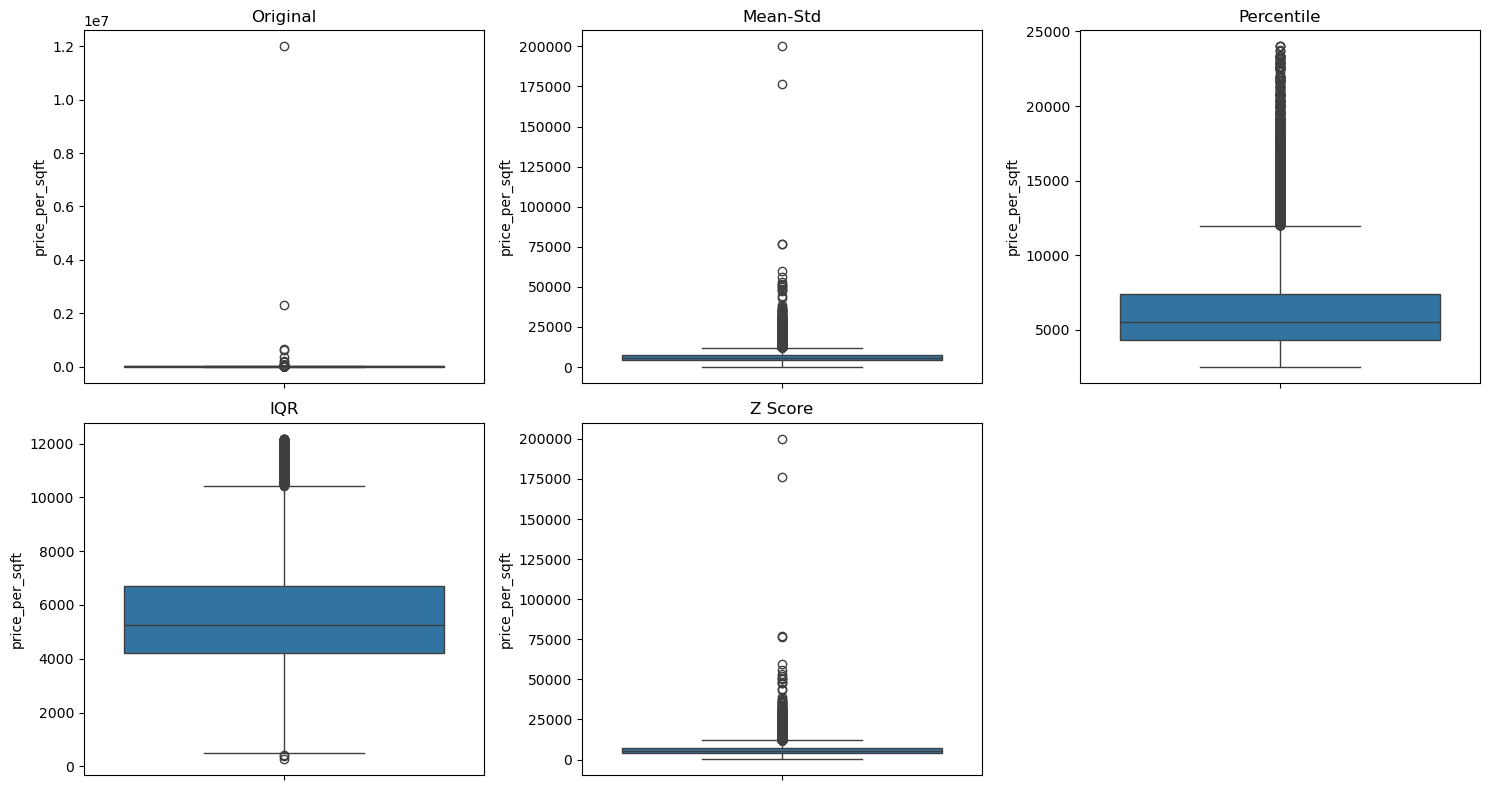

In [29]:
plt.figure(figsize=(15,8))

plt.subplot(2,3,1)
sns.boxplot(y=df[col])
plt.title("Original")

plt.subplot(2,3,2)
sns.boxplot(y=df_std[col])
plt.title("Mean-Std")

plt.subplot(2,3,3)
sns.boxplot(y=df_percentile[col])
plt.title("Percentile")

plt.subplot(2,3,4)
sns.boxplot(y=df_iqr[col])
plt.title("IQR")

plt.subplot(2,3,5)
sns.boxplot(y=df_z[col])
plt.title("Z Score")

plt.tight_layout()
plt.show()


### Insights:

**Boxplot of Original price_per_sqft**

* Many extreme outliers are present in the dataset.
* Most values are concentrated in lower price ranges.
* Distribution is highly right-skewed.

**Boxplot After Outlier Removal**

* Extreme outliers were reduced successfully.
* Data spread became more balanced.
* Remaining values appear more realistic.

Based on boxplot comparison and preservation of realistic observations, the IQR method appears to work best for this dataset. Since housing price per square feet is skewed, IQR is more robust than mean-based methods and effectively removes extreme outliers.

### 4.Histplot and Normality check


Before Transformation
Skewness: 103.88920549434168
Kurtosis: 11131.230839805381


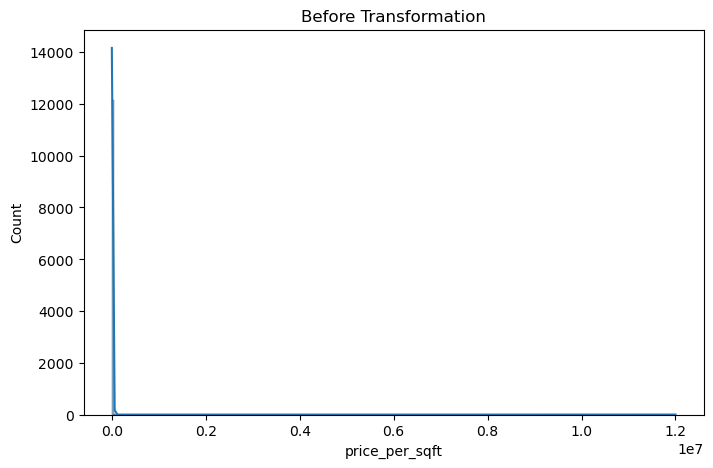

In [30]:
# Before transformation
print("\nBefore Transformation")
print("Skewness:", skew(df[col]))
print("Kurtosis:", kurtosis(df[col]))

plt.figure(figsize=(8,5))
sns.histplot(df[col], kde=True)
plt.title("Before Transformation")
plt.show()


### Insights:
* Distribution is positively skewed.
* Majority of properties have lower price per sqft.
* Few very high values stretch the distribution.


After Log Transformation
Skewness: 1.4008703544045937
Kurtosis: 9.40443454965253


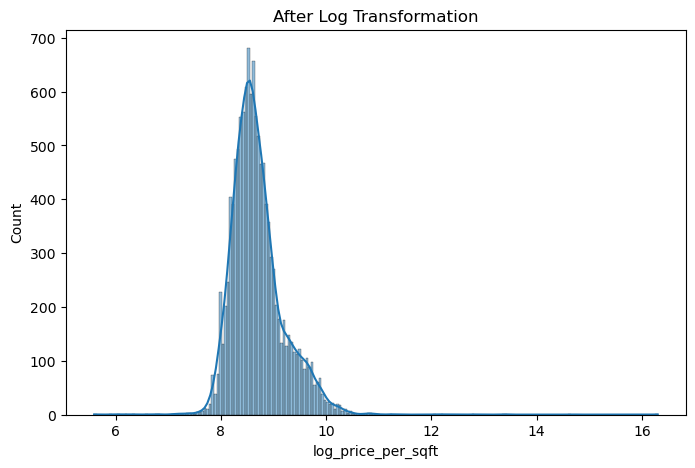

In [31]:
# Log Transformation
df['log_price_per_sqft'] = np.log1p(df[col])

print("\nAfter Log Transformation")
print("Skewness:", skew(df['log_price_per_sqft']))
print("Kurtosis:", kurtosis(df['log_price_per_sqft']))

plt.figure(figsize=(8,5))
sns.histplot(df['log_price_per_sqft'], kde=True)
plt.title("After Log Transformation")
plt.show()

### Insights
* Distribution became more symmetric after transformation.
* Skewness reduced significantly.
* Data is more suitable for modeling.

### 5.Correlation and Heatmap

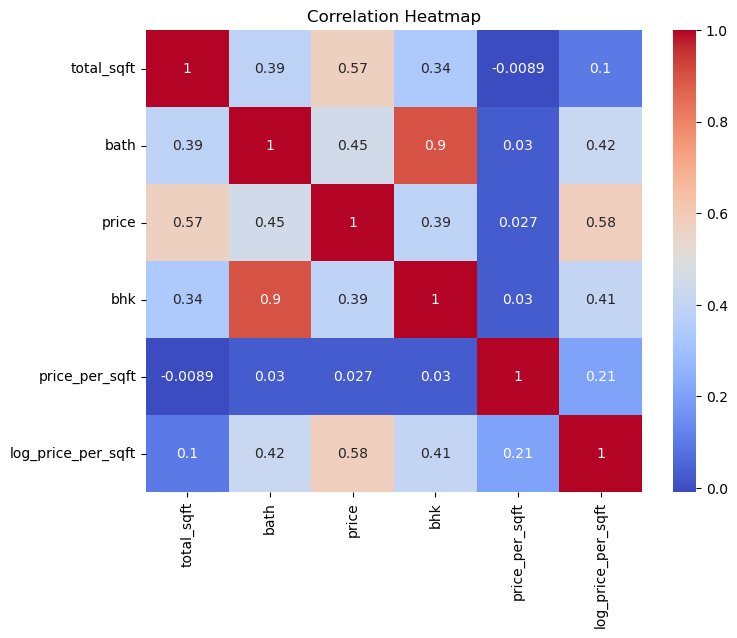

In [32]:
num_df = df.select_dtypes(include=np.number)

corr = num_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Insights
* Price has positive correlation with total_sqft and bhk.
* Bath and bhk are moderately related.
* No extremely strong multicollinearity found.

### 6.Scatter plots

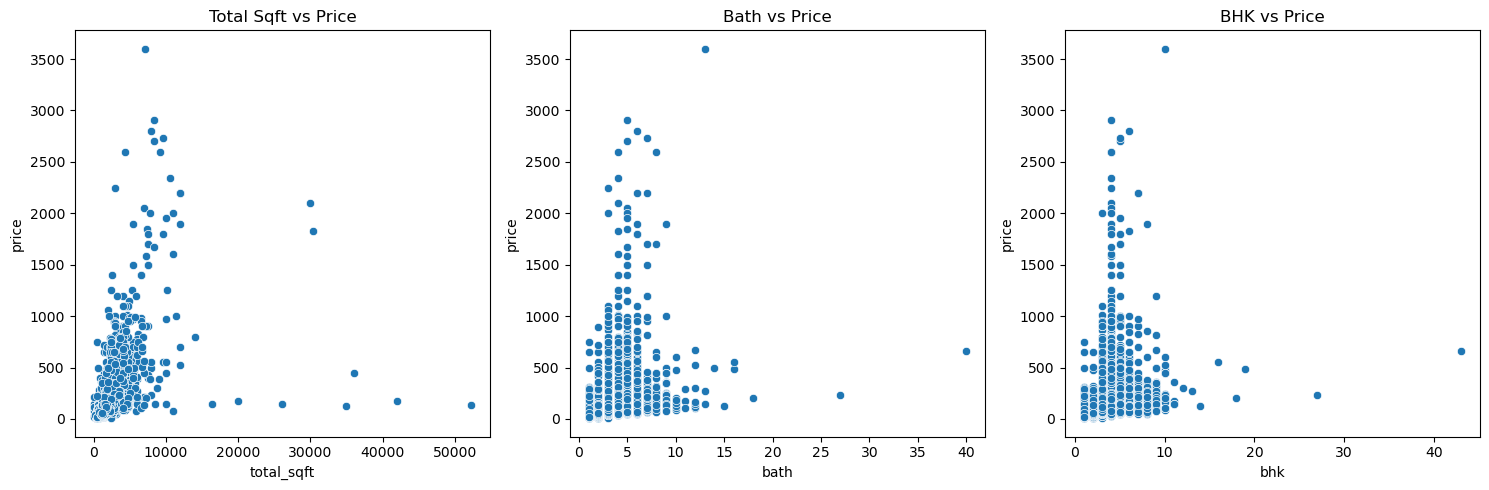

In [33]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.scatterplot(x=df['total_sqft'], y=df['price'])
plt.title("Total Sqft vs Price")

plt.subplot(1,3,2)
sns.scatterplot(x=df['bath'], y=df['price'])
plt.title("Bath vs Price")

plt.subplot(1,3,3)
sns.scatterplot(x=df['bhk'], y=df['price'])
plt.title("BHK vs Price")

plt.tight_layout()
plt.show()


### Insights:

**Total Sqft vs Price**

* As total square feet increases, price generally increases.
* Positive relationship is visible.
* Some high-value outliers are present.

**Bath vs Price**

* Houses with more bathrooms usually have higher prices.
* Relationship is positive but scattered.

**BHK vs Price**

* Higher BHK houses tend to have higher prices.
* Variation exists within each BHK category.

## Conclusion

* Dataset contains strong outliers in price_per_sqft.
* All four methods removed outliers successfully.
* IQR method usually gives balanced result.
* Log transformation reduced skewness.
* Heatmap helps understand numerical correlation.
* total_sqft and bhk show positive relation with price.